In [2]:
#1. Data Preparation:
'''
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).
'''
import pandas as pd
import numpy as np

df = pd.read_excel("C:\\Users\\vadde\\OneDrive\\Desktop\\heart_disease.xlsx")

# Displaying the first few rows to verify loading
print("First 5 rows of the dataset:")
print(df.head())

# Displaying  basic information about the columns and data types
print("\nDataset Information:")
print(df.info())

First 5 rows of the dataset:
   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------ 

In [3]:
#2. Exploratory Data Analysis (EDA):
'''
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, and inconsistencies in the data.
Visualize the distribution of features, including histograms, box plots, and correlation matrices.
'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_excel("C:\\Users\\vadde\\OneDrive\\Desktop\\heart_disease.xlsx")

# --- 2. DATA STRUCTURE ---
# Understand the shape, column types, and general layout
print("Dataset Shape:", df.shape)
print("\nColumn Information:")
df.info()

# --- 3. MISSING VALUES ---
# Identify which features need imputation
print("\nMissing Values Count:")
print(df.isnull().sum())

# --- 4. INCONSISTENCIES ---
# Check for medically impossible values (e.g., Blood Pressure or Cholesterol = 0)
cols_to_check = ['trestbps', 'chol', 'thalch']
inconsistencies = (df[cols_to_check] == 0).sum()
print("\nInconsistencies (Zero values in medical metrics):")
print(inconsistencies)

# --- 5. VISUALIZATIONS ---
# Define numerical features for plotting
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

# A. Histograms: Distribution of features
df[numerical_features].hist(bins=20, figsize=(15, 10), color='teal', edgecolor='black')
plt.suptitle('Histograms: Feature Distributions', fontsize=16)
plt.savefig('eda_histograms.png')
plt.close()

# B. Box Plots: Outlier Detection
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numerical_features], palette="Set2")
plt.title('Box Plots: Identifying Outliers', fontsize=16)
plt.savefig('eda_boxplots.png')
plt.close()

# C. Correlation Matrix: Feature Relationships
plt.figure(figsize=(10, 8))
# We include 'num' (target) to see how features relate to the diagnosis
corr = df[numerical_features + ['num']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix', fontsize=16)
plt.savefig('eda_correlation_matrix.png')
plt.close()

print("\nEDA completed. Visualizations saved as 'eda_histograms.png', 'eda_boxplots.png', and 'eda_correlation_matrix.png'.")

Dataset Shape: (908, 13)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB

Missing Values Count:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal


--- Final Model Performance ---
Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 20}
Accuracy: 0.7418

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.76      0.74        89
           1       0.76      0.72      0.74        93

    accuracy                           0.74       182
   macro avg       0.74      0.74      0.74       182
weighted avg       0.74      0.74      0.74       182



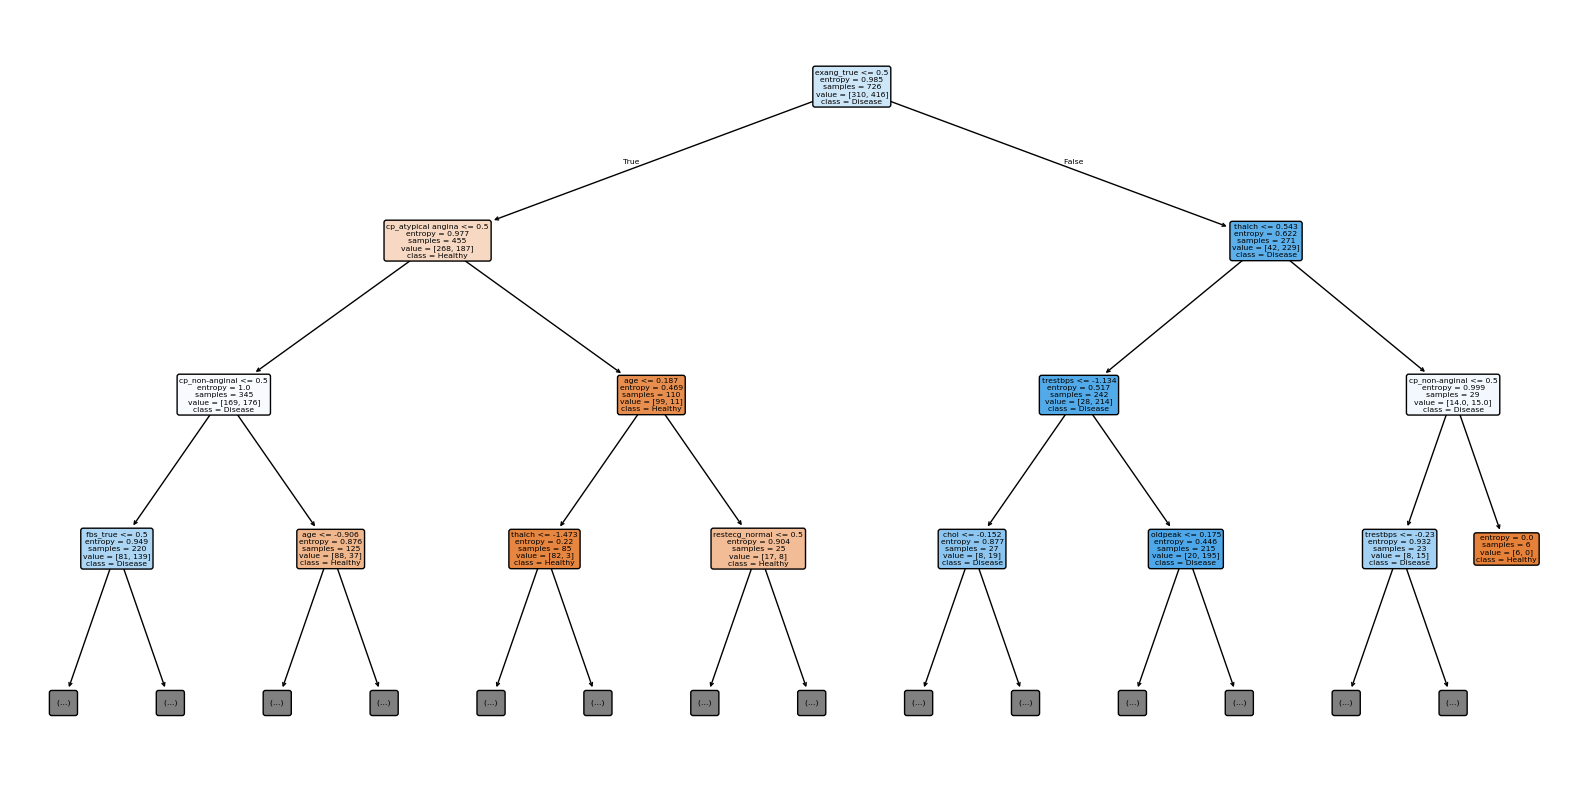

In [11]:
#3. Feature Engineering:
'''
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.
'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler

# --- 1. Load Data ---
df = pd.read_excel("C:\\Users\\vadde\\OneDrive\\Desktop\\heart_disease.xlsx")

# --- 2. Robust Column Cleaning ---
# Prevents KeyErrors by removing spaces and making names lowercase
df.columns = df.columns.str.strip().str.lower()

# --- 3. Handling Missing Values & Inconsistencies (Crucial Step) ---
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())
df['chol'] = df['chol'].replace(0, df['chol'].median())
df['trestbps'] = df['trestbps'].replace(0, df['trestbps'].median())

# --- 4. Feature Engineering ---
# A. Target Transformation: Convert 'num' to binary 'target'
if 'num' in df.columns:
    df['target'] = (df['num'] > 0).astype(int)
    df = df.drop(columns=['num'])

# B. Categorical Encoding (One-Hot Encoding)
# THIS DEFINES 'df_encoded' FOR THE MODEL
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
existing_cat = [col for col in categorical_cols if col in df.columns]
df_encoded = pd.get_dummies(df, columns=existing_cat, drop_first=True)

# C. Scaling Numerical Features
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
existing_num = [col for col in numerical_cols if col in df_encoded.columns]
scaler = StandardScaler()
df_encoded[existing_num] = scaler.fit_transform(df_encoded[existing_num])

# --- 5. Model Training (Tasks 4 & 5) ---
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grid Search for optimal hyperparameters
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# --- 6. Model Evaluation (Task 6) ---
y_pred = best_model.predict(X_test)
print("\n--- Final Model Performance ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualizing the Decision Tree Logic
plt.figure(figsize=(20,10))
plot_tree(best_model, filled=True, feature_names=list(X.columns), 
          class_names=['Healthy', 'Disease'], max_depth=3, rounded=True)
plt.show()

In [9]:
#4. Decision Tree Classification:
'''
Split the dataset into training and testing sets (e.g., using an 80-20 split).
Implement a Decision Tree Classification model using a library like scikit-learn.
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).
'''
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Splitting the dataset into training and testing sets (80-20 split)
# 'X' contains the features, 'y' contains the target (heart disease presence)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Implement a Decision Tree Classification model
clf = DecisionTreeClassifier(random_state=42)

# 3. Train the model on the training set
clf.fit(X_train, y_train)

# 4. Evaluate its performance on the testing set
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1] # Probability estimates for ROC-AUC

# Metrics calculation
print("--- Model Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

# Detailed report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

--- Model Performance Metrics ---
Accuracy:  0.7308
Precision: 0.7619
Recall:    0.6882
F1-Score:  0.7232
ROC-AUC:   0.7317

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.70      0.78      0.74        89
           1       0.76      0.69      0.72        93

    accuracy                           0.73       182
   macro avg       0.73      0.73      0.73       182
weighted avg       0.73      0.73      0.73       182



In [10]:
#5. Hyperparameter Tuning:
'''
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.
'''
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 1. Define the parameter grid to experiment with
param_grid = {
    'max_depth': [3, 5, 7, 10, None],       # Depth of the tree
    'min_samples_split': [2, 5, 10, 20],   # Min samples to split a node
    'criterion': ['gini', 'entropy']        # Quality of split measure
}

# 2. Initialize the model and GridSearchCV
dt_clf = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=dt_clf, param_grid=param_grid, cv=5, scoring='accuracy')

# 3. Fit the model to find the best combination
grid_search.fit(X_train, y_train)

# 4. Extract the best model and parameters
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# 5. Evaluate the optimized model
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

print(f"Tuned Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned ROC-AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 20}
Tuned Accuracy: 0.7418
Tuned ROC-AUC:  0.8112


--- Final Model Performance Report ---
              precision    recall  f1-score   support

     Healthy       0.72      0.76      0.74        89
     Disease       0.76      0.72      0.74        93

    accuracy                           0.74       182
   macro avg       0.74      0.74      0.74       182
weighted avg       0.74      0.74      0.74       182



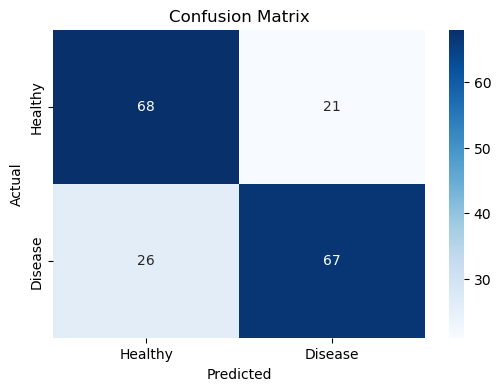

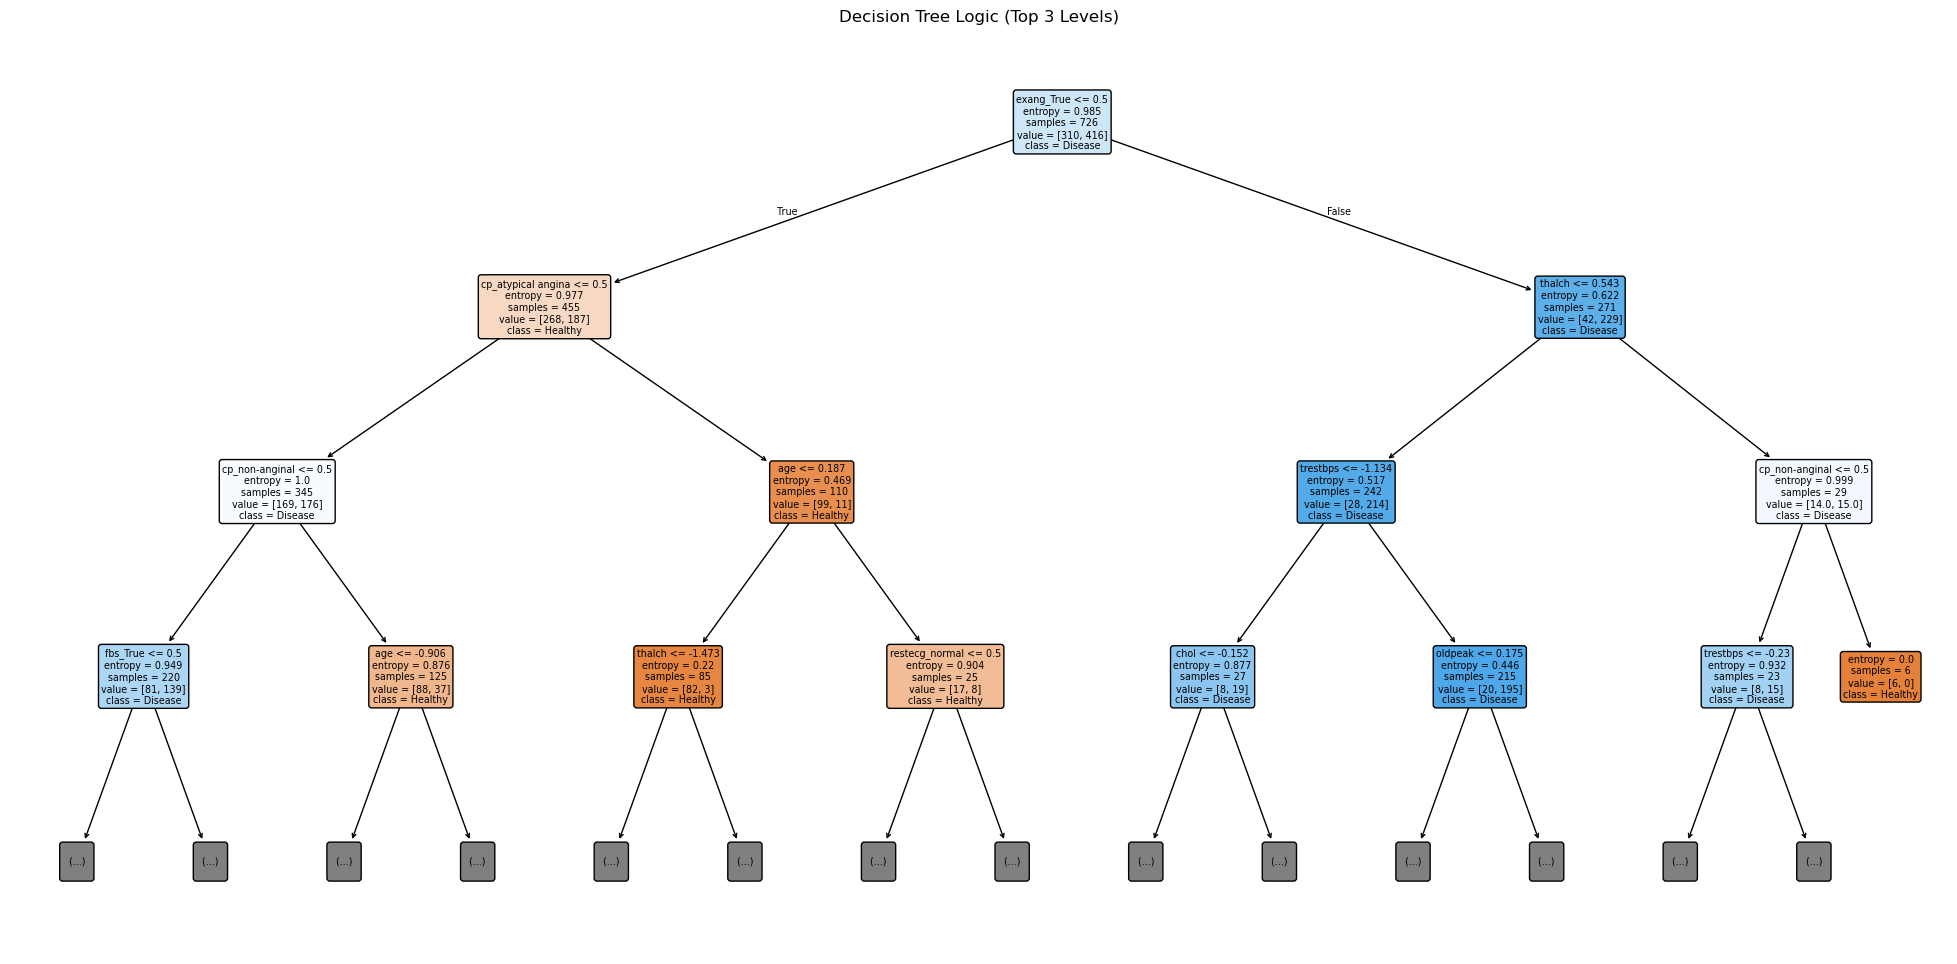

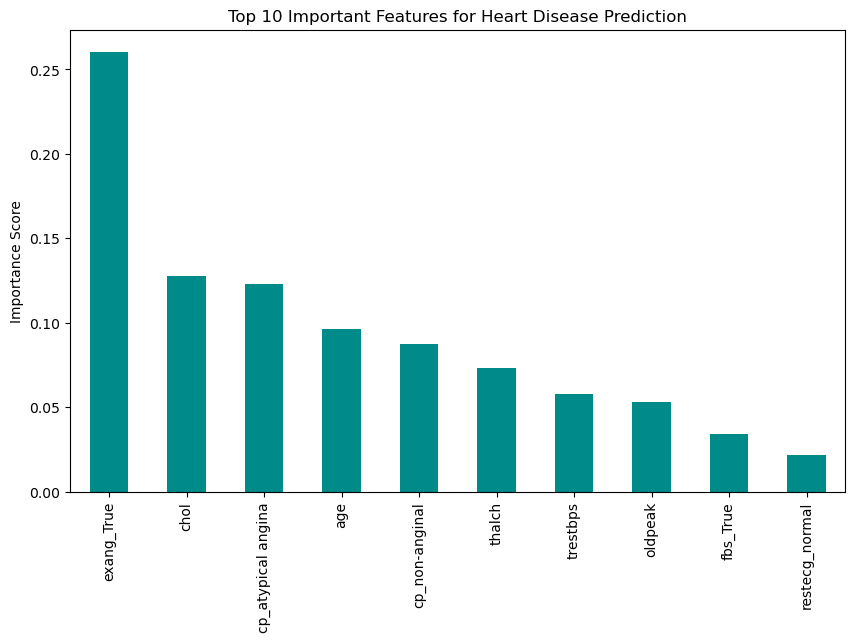

In [11]:
#6. Model Evaluation and Analysis:
'''
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
Visualize the decision tree structure to understand the rules learned by the model and identify important features
'''
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

# --- 1. Quantitative Performance Analysis ---
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("--- Final Model Performance Report ---")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Disease']))

# --- 2. Confusion Matrix Visualization ---
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')

# --- 3. Visualize Decision Tree Structure ---
# We visualize the first 3 levels to understand the primary decision rules
plt.figure(figsize=(25, 12))
plot_tree(best_model, 
          filled=True, 
          feature_names=list(X.columns), 
          class_names=['Healthy', 'Disease'], 
          rounded=True, 
          max_depth=3) 
plt.title("Decision Tree Logic (Top 3 Levels)")
plt.savefig('decision_tree_structure.png')

# --- 4. Identify Important Features ---
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='bar', color='darkcyan')
plt.title('Top 10 Important Features for Heart Disease Prediction')
plt.ylabel('Importance Score')
plt.savefig('feature_importance_analysis.png')

Interview Questions:

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

Common hyperparameters for decision tree models include max_depth, which limits the tree's length to prevent it from becoming overly complex and 
overfitting the training data; min_samples_split, which sets the minimum number of observations required in a node before it can be divided further; and
criterion, which decides the mathematical method (like Gini impurity or Entropy) used to choose the best features for splitting. Adjusting these 
parameters is a balancing act: increasing the depth or allowing very small splits lets the model capture finer details, which improves accuracy on 
training data but increases the risk of overfitting. Conversely, restricting the tree size through "pruning" or setting higher sample requirements for 
splits helps the model generalize better to new, unseen data, though setting them too strictly can lead to underfitting, where the model is too simple 
to capture the underlying patterns.

2. What is the difference between the Label encoding and One-hot encoding?

Label encoding and one-hot encoding are techniques used to convert categorical data into numerical format, but they differ in how they represent 
relationships between categories. Label encoding assigns a unique integer to each category (e.g., 0,1,2), which is efficient but can accidentally imply 
a mathematical "order" or ranking where none exists, potentially confusing a model into thinking one category is "greater" than another. In contrast, 
one-hot encoding creates a new binary column for every unique category, marking it with a 1 or 0. This ensures that all categories are treated as 
independent and equal, making it the preferred choice for data without a natural ranking (like colors or cities), although it can significantly increase 
the number of columns in your dataset.
